In [62]:
#Parte 1 de la tarea


In [63]:
import numpy as np
import pandas as pd
import random as random
import matplotlib.pyplot as plt

In [64]:
semilla = 223
rng = np.random.default_rng(semilla)

Las 5 variables aleatorias serán $\Gamma(\alpha, \beta)$, $N(\mu, \sigma^2)$, $Unif([a,b])$, $Bin(n,p)$ y $Poiss(\lambda)$. Se ejecutarán 1000 lanzamientos de c/u y sus parametros son:  <br>
i) para la Gamma: $\alpha=10, \ \beta=0.5$. <br>
ii) para la Normal $\mu=0, \ \sigma=5$. <br>
iii) para la Uniforme $a=0, \ b=10$. <br>
iv) para la Binomial $n=5, \ p=0.6$. <br>
v) para la Poisson $\lambda = 10$. 


In [66]:
rs_gamma= rng.gamma(shape=10,scale=0.5,size=1000)

rs_normal= rng.normal(loc=0,scale=5,size=1000)

rs_uniforme= rng.uniform(low=0,high=10,size=1000)

rs_binomial= rng.binomial(n=5,p=0.6,size=1000)

rs_poisson= rng.poisson(lam=10,size=1000)

In [67]:
cantidad= np.arange(1, len(rs_gamma) + 1)

suma_gamma= np.cumsum(rs_gamma)
prom_gamma= suma_gamma/cantidad

suma_normal= np.cumsum(rs_normal)
prom_normal= suma_normal/cantidad

suma_uniforme= np.cumsum(rs_uniforme)
prom_uniforme= suma_uniforme/cantidad

suma_binomial= np.cumsum(rs_binomial)
prom_bionomial= suma_binomial/cantidad

suma_poisson= np.cumsum(rs_poisson)
prom_poisson= suma_poisson/cantidad

In [68]:
df_lgn = pd.DataFrame({
    "Gamma P.A.":prom_gamma,"Normal P.A.":prom_normal,"Uniforme P.A.":prom_uniforme,"Binomial P.A.":prom_bionomial,"Poisson P.A.":prom_poisson,
})

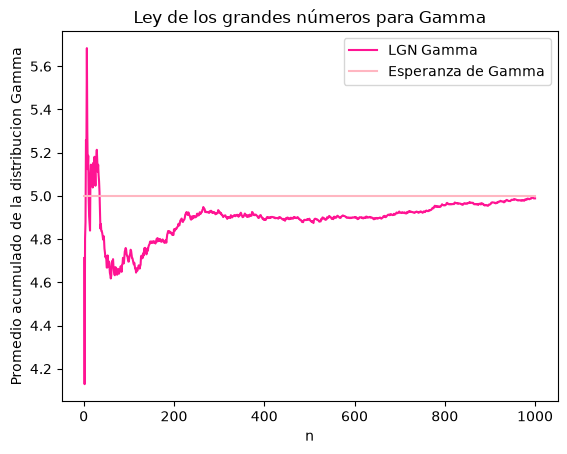

In [69]:
esperanza_gamma= np.full(len(cantidad), 10*0.5)
plt.plot(cantidad, df_lgn["Gamma P.A."], color="deeppink",label="LGN Gamma")
plt.plot(cantidad, esperanza_gamma, color="lightpink",label="Esperanza de Gamma")
plt.xlabel("n")
plt.ylabel("Promedio acumulado de la distribucion Gamma")
plt.title("Ley de los grandes números para Gamma")
plt.legend()
plt.savefig("../results/lgn_gamma.png")
plt.show()

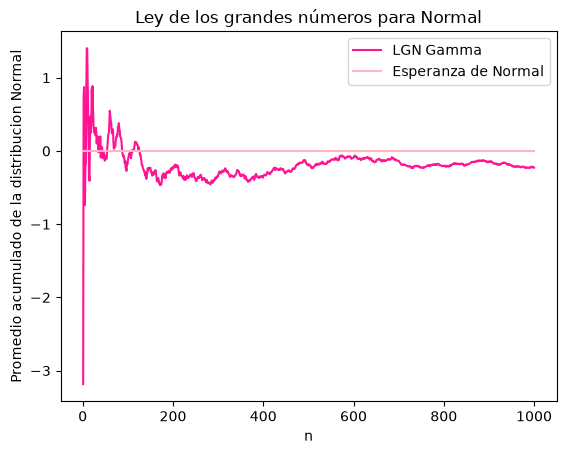

In [70]:
esperanza_normal= np.full(len(cantidad),0)
plt.plot(cantidad, df_lgn["Normal P.A."], color="deeppink",label="LGN Gamma")
plt.plot(cantidad, esperanza_normal, color="lightpink",label="Esperanza de Normal")
plt.xlabel("n")
plt.ylabel("Promedio acumulado de la distribucion Normal")
plt.title("Ley de los grandes números para Normal")
plt.legend()
plt.savefig("../results/lgn_normal.png")
plt.show()

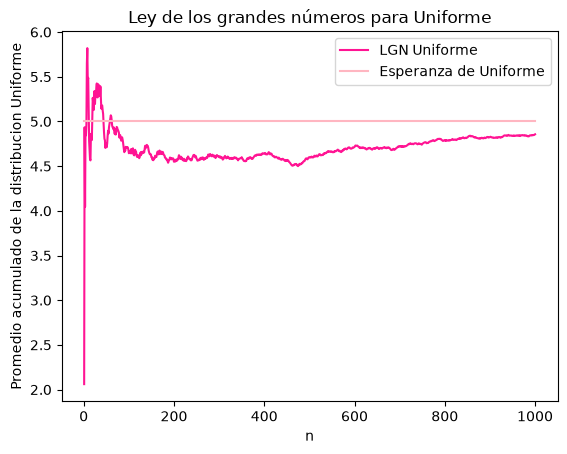

In [71]:
esperanza_uniforme= np.full(len(cantidad), (0+10)/2)
plt.plot(cantidad, df_lgn["Uniforme P.A."], color="deeppink",label="LGN Uniforme")
plt.plot(cantidad, esperanza_uniforme, color="lightpink",label="Esperanza de Uniforme")
plt.xlabel("n")
plt.ylabel("Promedio acumulado de la distribucion Uniforme")
plt.title("Ley de los grandes números para Uniforme")
plt.legend()
plt.savefig("../results/lgn_uniforme.png")
plt.show()

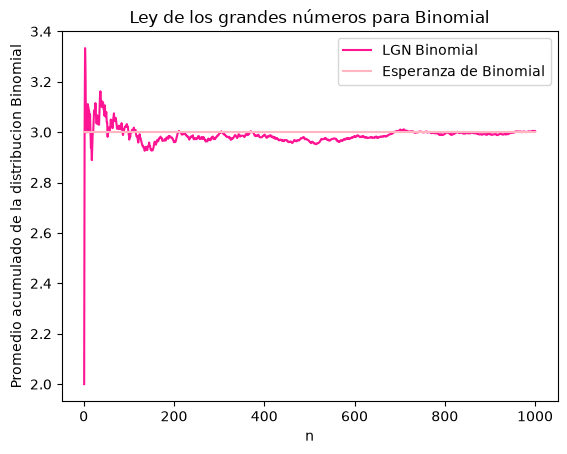

In [72]:
esperanza_binomial= np.full(len(cantidad),5*0.6)
plt.plot(cantidad, df_lgn["Binomial P.A."], color="deeppink",label="LGN Binomial")
plt.plot(cantidad, esperanza_binomial, color="lightpink",label="Esperanza de Binomial")
plt.xlabel("n")
plt.ylabel("Promedio acumulado de la distribucion Binomial")
plt.title("Ley de los grandes números para Binomial")
plt.legend()
plt.savefig("../results/lgn_binomial.png")
plt.show()

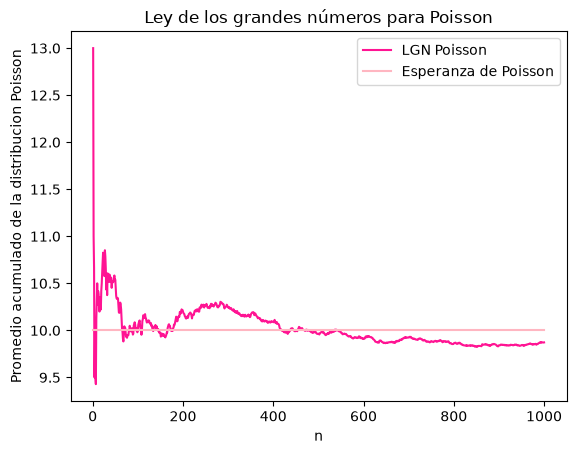

In [73]:
esperanza_poisson= np.full(len(cantidad),10)
plt.plot(cantidad, df_lgn["Poisson P.A."], color="deeppink",label="LGN Poisson")
plt.plot(cantidad, esperanza_poisson, color="lightpink",label="Esperanza de Poisson")
plt.xlabel("n")
plt.ylabel("Promedio acumulado de la distribucion Poisson")
plt.title("Ley de los grandes números para Poisson")
plt.legend()
plt.savefig("../results/lgn_poisson.png")
plt.show()

Ahora para el estudio del TCL, lo haremos basandonos en la misma distribución $\Gamma(\alpha, \beta)$ con $\alpha=10$, $\beta=0.5$ y $n=1000$.

In [118]:
#Los valores de la variable aleatoria sin normalizar es una normal de media 5 y varianza 2,5/n
N , ng , b =5000 , 5000 ,50

In [119]:
rs_gamma_2= rng.gamma(shape=10,scale=0.5,size=(N,ng))
sumas_fila= np.sum(rs_gamma_2,axis=1)
promedio_gamma2 = sumas_fila/ng

mu1 , sigma1 = 5, np.sqrt(2.5/ng)
normal_sn = rng.normal(loc=mu1,scale=sigma1,size=ng)


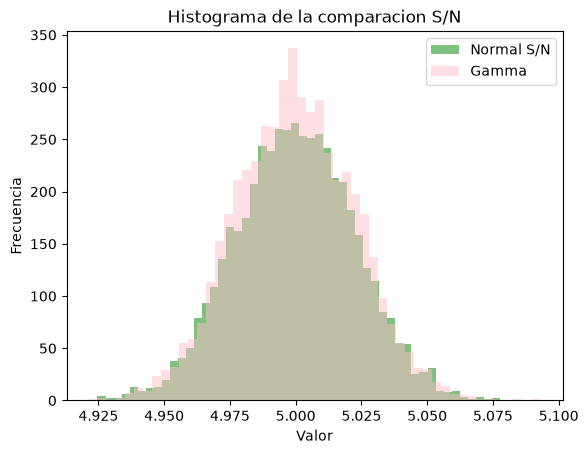

In [120]:

plt.hist(normal_sn,bins=b,color="green",alpha=0.5,label="Normal S/N")
plt.hist(promedio_gamma2,bins=b,color="pink",alpha=0.5,label="Gamma")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.title("Histograma de la comparacion S/N")
plt.legend()
plt.savefig("../results/tlc_no_normalizada.png")
plt.show()

Ahora con la variable normalizada

In [121]:
variable_normalizada = (promedio_gamma2 - mu1)/(sigma1)
normal_n = rng.normal(loc=0,scale=1,size=ng)

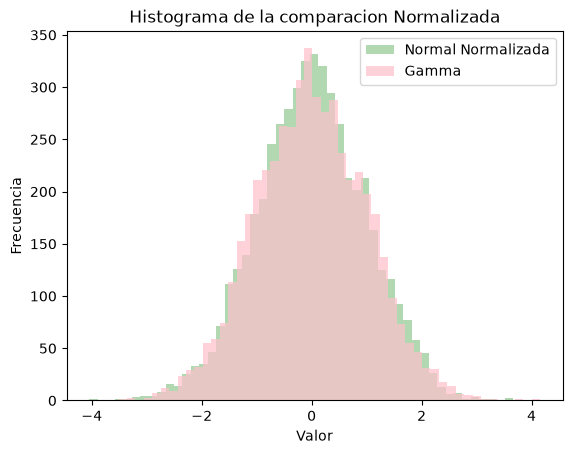

In [122]:
plt.hist(normal_n,bins=b,color="green",alpha=0.3,label="Normal Normalizada")
plt.hist(variable_normalizada,bins=b,color="pink",alpha=0.7,label="Gamma")
plt.xlabel("Valor")
plt.ylabel("Frecuencia")
plt.title("Histograma de la comparacion Normalizada")
plt.legend()
plt.savefig("../results/tlc_normalizada.png")
plt.show()